# BCI for Inner Speech Classification

## Preprocessing, Feature Extraction and Baseline SVM


In [156]:
# Import required libraries
import mne
import warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
import sys
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from mne.decoding import CSP

# Add the Inner Speech Dataset repository to the system path
project_root = Path.cwd()
print(f"Current working directory: {project_root}")
if not (project_root / "Python_Processing").exists():
    project_root = project_root / "Inner_Speech_Dataset-main"
sys.path.insert(0, str(project_root / "Python_Processing"))
print(f"Python_Processing directory added to system path: {sys.path[0]}")

# Import custom functions from the Inner Speech Dataset repository
from lib.data_extractions import (
    extract_data_from_subject,
)
from lib.data_processing import (
    select_time_window,
    transform_for_classificator,
)

from lib.download_helper import (
    _clone_inner_speech,
    get_derivatives,
)


# Set random seed for reproducibility
np.random.seed(23)

# Configure MNE to show only warnings (suppress info messages)
mne.set_log_level(verbose="warning")

# Suppress deprecation and future warnings
warnings.filterwarnings(action="ignore", category=DeprecationWarning)
warnings.filterwarnings(action="ignore", category=FutureWarning)

print("Setup complete! All libraries imported successfully.")

Current working directory: d:\Documents\code\comp neuro\Inner_Speech_Dataset-main
Python_Processing directory added to system path: d:\Documents\code\comp neuro\Inner_Speech_Dataset-main\Python_Processing
Setup complete! All libraries imported successfully.


In [ ]:

# Using this path to download the dataset
data_dir = Path().resolve().parent

# Clone just the structure (no files yet). This step is needed to create the
data_dir = _clone_inner_speech(target_dir=data_dir, verbose=False)

# Download the files needed for this script. This can take some minutes.
get_derivatives(
    dataset_path=data_dir,
    subjects="all",
    sessions="all",
    file_types=["eeg","events"],
    verbose=True,
    progress=True,
)


parameters

In [158]:
# Original sampling rate
sfreq = 256

# Target sampling rate
target_sfreq = 128

# Filtering parameters
lowcut = 1.0
highcut = 40.0

notch_freq = 50.0  # use 60 if your environment uses 60Hz mains

# Epoch window
tmin = 0.0
tmax = 2.0

In [159]:
def resample_data(X, original_sfreq, target_sfreq):
    """
    X shape: [trials, channels, time]
    """
    n_trials, n_channels, _ = X.shape

    resampled_trials = []

    for trial in X:
        trial_resampled = mne.filter.resample(
            trial,
            down=original_sfreq / target_sfreq,
            npad="auto"
        )
        resampled_trials.append(trial_resampled)

    return np.array(resampled_trials)

In [160]:
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')
    return b, a


def apply_bandpass(X, lowcut, highcut, fs):
    b, a = butter_bandpass(lowcut, highcut, fs)

    filtered = np.zeros_like(X)

    for i in range(X.shape[0]):
        for ch in range(X.shape[1]):
            filtered[i, ch] = filtfilt(b, a, X[i, ch])

    return filtered

In [161]:
def apply_notch_filter(X, notch_freq, fs, quality=30):
    b, a = iirnotch(notch_freq, quality, fs)

    filtered = np.zeros_like(X)

    for i in range(X.shape[0]):
        for ch in range(X.shape[1]):
            filtered[i, ch] = filtfilt(b, a, X[i, ch])

    return filtered

In [162]:
def baseline_correction(X):
    """
    Subtract mean over time for each channel.
    """
    baseline = np.mean(X, axis=2, keepdims=True)
    return X - baseline

In [163]:
def remove_artifacts(X, threshold=100):
    """
    Remove trials with extreme amplitudes.
    """
    keep_trials = []

    for i in range(X.shape[0]):
        if np.max(np.abs(X[i])) < threshold:
            keep_trials.append(i)

    return X[keep_trials], keep_trials

In [165]:
csp = CSP(
    n_components=8,
    reg='ledoit_wolf',
    log=True,
    norm_trace=False
)

In [166]:
def plot_trial_comparison(X_raw, X_filt, trial=0, channel=0):
    t = np.arange(X_raw.shape[2]) / 128  # after resample

    plt.figure(figsize=(12,5))
    plt.plot(t, X_raw[trial, channel], label="Raw", alpha=0.7)
    plt.plot(t, X_filt[trial, channel], label="Filtered", alpha=0.8)

    plt.title(f"Trial {trial} - Channel {channel}")
    plt.legend()
    plt.show()

In [167]:
def plot_class_average(X, Y, channel=10):
    t = np.arange(X.shape[2]) / 128

    class0 = X[Y == 0][:, channel, :]
    class1 = X[Y == 1][:, channel, :]

    plt.figure(figsize=(10,5))
    plt.plot(t, class0.mean(axis=0), label="Class 0 (Up)")
    plt.plot(t, class1.mean(axis=0), label="Class 1 (Down)")

    plt.title("Class-wise Average EEG Signal")
    plt.legend()
    plt.show()

## 3. Understanding the Data Structure

The Inner Speech Dataset is organized as follows:

- **Subjects**: 10 participants (numbered 1-10)
- **Sessions**: Each subject completed 3 experimental blocks/sessions
- **Conditions**: Each trial belongs to one of three conditions:
  - Pronounced (spoken out loud)
  - Inner Speech (thinking only)  
  - Visualized (mentally visualized)
- **Classes**: Each trial involves thinking about one direction:
  - Up
  - Down
  - Left
  - Right

### Data Types Available:
1. **EEG**: Brain activity from 128 electrodes on the scalp
2. **EXG**: External physiological signals including:
   - EMG (electromyography) - muscle activity
   - EOG (electrooculography) - eye movements
   - ECG (electrocardiography) - heart activity
3. **Baseline**: Resting state brain activity when no task is performed

Let's now set up the parameters for our analysis:

In [168]:
# Set the hyperparameters for data loading and processing

# Directory containing the dataset (adjust this to your local path)
root_dir = Path.cwd().parent / "ds003626" # Path to the dataset

# Specify which type of data to use
# Options: "EEG" (brain activity), "exg" (physiological signals), or "baseline" (resting state)
datatype = "EEG"

# EEG sampling rate (256 samples per second)
fs = 256

# Select the time window of interest (in seconds)
# The cue appears at t=0, action period is between 1.5s and 3.5s
t_start = 1.5  # Start time after cue
t_end = 3.5  # End time after cue

# Subject to analyze (1-10)
N_S = 1  # We'll start with subject 1

print(
    f"Parameters set: Using {datatype} data from subject {N_S}, analyzing time window {t_start}s to {t_end}s"
)

Parameters set: Using EEG data from subject 1, analyzing time window 1.5s to 3.5s


## 4. Loading and Exploring the Data

Now we'll load data from the selected subject. The dataset contains three experimental blocks for each subject, and our custom function will automatically load and combine all blocks.

The data is returned in two arrays:
- **X**: The EEG signals [trials × channels × time points]
- **Y**: The event labels [trials × 4], where each row contains:
  - Column 0: Timestamp
  - Column 1: Direction class (0=up, 1=down, 2=right, 3=left)
  - Column 2: Condition (0=pronounced, 1=inner speech, 2=visualized)
  - Column 3: Session number

Let's load the data and examine its structure:

In [169]:
# Load all trials for the selected subject
# This combines data from all three experimental blocks
X, Y = extract_data_from_subject(root_dir, N_S, datatype)

print("Data successfully loaded!")
print("\nX (EEG data) shape:", X.shape)
print("  - Number of trials:", X.shape[0])
print("  - Number of EEG channels:", X.shape[1])
print("  - Number of time points per trial:", X.shape[2])
print("  - Total duration per trial:", X.shape[2] / fs, "seconds")

print("\nY (labels) shape:", Y.shape)
print("  - Number of trials:", Y.shape[0])
print("  - Label information columns:", Y.shape[1])

# Check how many trials we have of each condition and direction
conditions = ["Pronounced", "Inner Speech", "Visualized"]
directions = ["Up", "Down", "Right", "Left"]

print("\nNumber of trials per condition:")
for i, condition in enumerate(conditions):
    condition_count = np.sum(Y[:, 2] == i)
    print(f"{condition}: {condition_count}")

print("\nNumber of trials per direction:")
for i, direction in enumerate(directions):
    direction_count = np.sum(Y[:, 1] == i)
    print(f"{direction}: {direction_count}")

Data successfully loaded!

X (EEG data) shape: (500, 128, 1153)
  - Number of trials: 500
  - Number of EEG channels: 128
  - Number of time points per trial: 1153
  - Total duration per trial: 4.50390625 seconds

Y (labels) shape: (500, 4)
  - Number of trials: 500
  - Label information columns: 4

Number of trials per condition:
Pronounced: 100
Inner Speech: 200
Visualized: 200

Number of trials per direction:
Up: 125
Down: 125
Right: 125
Left: 125


## 5. Data Processing - Selecting the Relevant Time Window

The trials in this dataset are recorded over a longer time period than we need. Each trial includes:

- Pre-stimulus period (-0.5 to 0s)
- Cue presentation (0 to 0.5s)
- Action period (0.5 to 3.5s) 
- Rest period (3.5 to 4s)

For classification, we want to focus on the period when the subject is actively thinking about the direction. Based on the experimental design, this occurs between 1.5 and 3.5 seconds after the cue.

Let's select this time window from our data:

In [170]:
# Extract only the relevant time window from each trial
# X goes from [trials × channels × full_time_points] to [trials × channels × selected_time_points]
X = select_time_window(X=X, t_start=t_start, t_end=t_end, fs=fs)

print("Time window selection complete!")
print("\nNew X (EEG data) shape:", X.shape)
print("  - Number of trials:", X.shape[0])
print("  - Number of EEG channels:", X.shape[1])
print("  - Number of time points per trial:", X.shape[2])
print("  - Selected duration per trial:", X.shape[2] / fs, "seconds")

# Calculate how many data points were selected
total_data_points = X.shape[0] * X.shape[1] * X.shape[2]
print(f"\nTotal data points in selected window: {total_data_points:,}")

Time window selection complete!

New X (EEG data) shape: (500, 128, 512)
  - Number of trials: 500
  - Number of EEG channels: 128
  - Number of time points per trial: 512
  - Selected duration per trial: 2.0 seconds

Total data points in selected window: 32,768,000


In [171]:
# First, let's reload the original data for our subject
X, Y = extract_data_from_subject(root_dir, N_S, datatype)

# Extract only the relevant time window
X = select_time_window(X=X, t_start=t_start, t_end=t_end, fs=fs)

# Define which conditions and classes we want to compare
# We'll compare "Up" vs "Down" in the "Inner Speech" condition
Conditions = [["Inner"], ["Inner"]]  # All groups use Inner Speech condition
Classes = [["Up"], ["Down"]]  # First group is "Up", second is "Down"

print("Filtering data to compare:")
print(f"- Group 1: {Classes[0][0]} direction in {Conditions[0][0]} condition")
print(f"- Group 2: {Classes[1][0]} direction in {Conditions[1][0]} condition")
# print(f"- Group 3: {Classes[2][0]} direction in {Conditions[2][0]} condition")
# print(f"- Group 4: {Classes[3][0]} direction in {Conditions[3][0]} condition")

# Transform and filter the data to keep only trials of interest
X, Y = transform_for_classificator(X, Y, Classes, Conditions)



print("\nAfter filtering:")
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("\nY now contains simple binary labels:")
print("- 0 represents:", Classes[0][0])
print("- 1 represents:", Classes[1][0])

# Check how many trials we have for each class
n_up = np.sum(Y == 0)
n_down = np.sum(Y == 1)
# n_left = np.sum(Y == 2)
# n_right = np.sum(Y == 3)

print(f"\nNumber of '{Classes[0][0]}' trials: {n_up}")
print(f"Number of '{Classes[1][0]}' trials: {n_down}")
# print(f"Number of '{Classes[2][0]}' trials: {n_left}")
# print(f"Number of '{Classes[3][0]}' trials: {n_right}")

Filtering data to compare:
- Group 1: Up direction in Inner condition
- Group 2: Down direction in Inner condition

After filtering:
X shape: (100, 128, 512)
Y shape: (100,)

Y now contains simple binary labels:
- 0 represents: Up
- 1 represents: Down

Number of 'Up' trials: 50
Number of 'Down' trials: 50


In [172]:
selected_channels = np.arange(128)

X = X[:, selected_channels, :]

In [173]:
# Step 1: Resample
X = resample_data(X, sfreq, target_sfreq)

# Step 2: Bandpass filter
X = apply_bandpass(X, lowcut, highcut, target_sfreq)

# Step 3: Notch filter
X = apply_notch_filter(X, notch_freq, target_sfreq)

# Step 4: Baseline correction
# X = baseline_correction(X)

# Step 5: Artifact removal
# X, kept_indices = remove_artifacts(X)

# Y = Y[kept_indices]

print("Preprocessing complete.")
print("Processed X shape:", X.shape)

Preprocessing complete.
Processed X shape: (100, 128, 256)


In [174]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state= 23,
    stratify=Y
)

In [175]:
X_train_alpha = bandpass(X_train, 8, 12, fs=128)
X_test_alpha  = bandpass(X_test, 8, 12, fs=128)

X_train_beta = bandpass(X_train, 13, 30, fs=128)
X_test_beta  = bandpass(X_test, 13, 30, fs=128)

csp_alpha = CSP(n_components=4, log=True)
csp_beta  = CSP(n_components=4, log=True)

X_train_a = csp_alpha.fit_transform(X_train_alpha, y_train)
X_test_a  = csp_alpha.transform(X_test_alpha)

X_train_b = csp_beta.fit_transform(X_train_beta, y_train)
X_test_b  = csp_beta.transform(X_test_beta)

X_train_final = np.hstack([X_train_a, X_train_b])
X_test_final  = np.hstack([X_test_a, X_test_b])

In [176]:
clf = Pipeline([
    ('CSP', csp),
    # ('Scaler', StandardScaler()),
    ('SVM', SVC(kernel='linear' ))
])

print("Training CSP + SVM pipeline...")

clf.fit(X_train_final, y_train)

y_pred = clf.predict(X_test_final)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc * 100:.2f}%")

Training CSP + SVM pipeline...
Accuracy: 66.67%


In [177]:
print(X.shape)
print(np.unique(Y, return_counts=True))
print(X_test.shape)
print(y_test.shape)

(100, 128, 256)
(array([0., 1.]), array([50, 50]))
(30, 128, 256)
(30,)


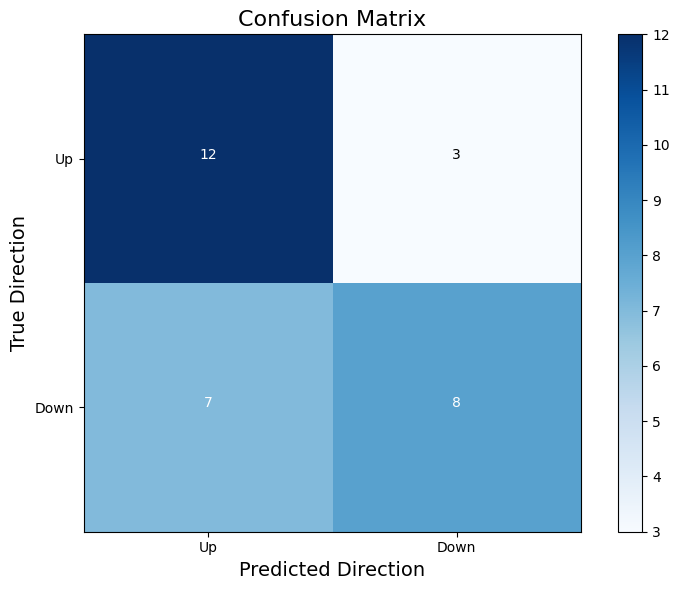


The confusion matrix shows:
- True Up, predicted Up: 12 trials
- True Up, predicted Down: 3 trials
- True Down, predicted Up: 7 trials
- True Down, predicted Down: 8 trials


In [178]:

# Create and display confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix", fontsize=16)
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Up", "Down"])
plt.yticks(tick_marks, ["Up", "Down"])
plt.xlabel("Predicted Direction", fontsize=14)
plt.ylabel("True Direction", fontsize=14)

# Add text annotations to the confusion matrix
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
        )

plt.tight_layout()
plt.show()

print("\nThe confusion matrix shows:")
print(f"- True Up, predicted Up: {cm[0,0]} trials")
print(f"- True Up, predicted Down: {cm[0,1]} trials")
print(f"- True Down, predicted Up: {cm[1,0]} trials")
print(f"- True Down, predicted Down: {cm[1,1]} trials")

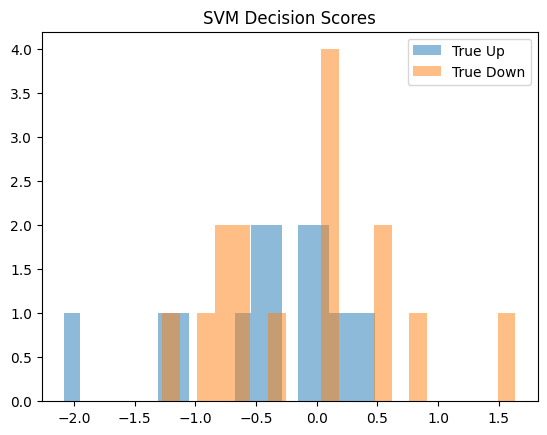

In [180]:
scores = clf.decision_function(X_test_final)

plt.hist(scores[y_test == 0], bins=20, alpha=0.5, label="True Up")
plt.hist(scores[y_test == 1], bins=20, alpha=0.5, label="True Down")
plt.legend()
plt.title("SVM Decision Scores")
plt.show()

In [181]:
from sklearn.metrics import roc_auc_score
print("AUC:", roc_auc_score(y_test, scores))

AUC: 0.6044444444444443




## References

- Inner Speech Dataset: https://github.com/N-Nieto/Inner_Speech_Dataset

## Citing this work

Please cite this work.
```bibtex
@article{nieto2022thinking,
  title={Thinking out loud, an open-access EEG-based BCI dataset for inner speech recognition},
  author={Nieto, Nicol{\'a}s and Peterson, Victoria and Rufiner, Hugo Leonardo and Kamienkowski, Juan Esteban and Spies, Ruben},
  journal={Scientific Data},
  volume={9},
  number={1},
  pages={1--17},
  year={2022},
  publisher={Nature Publishing Group}
}

```
```bibtex
@article{nieto2021inner,
  title={Inner Speech},
  author={Nieto, N and Peterson, V and Rufiner, HL and Kamienkowski, JE and Spies, R},
  journal={OpenNeuro},
  volume={29},
  pages={227--236},
  year={2021}
}
```